<a href="https://colab.research.google.com/github/7amokarim/NYC-Complaints-Data-Analysis/blob/main/NYC_Complaints_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# تحميل أول 100,000 سجل من البيانات
url = 'https://data.cityofnewyork.us/resource/erm2-nwe9.csv?$limit=100000'
df = pd.read_csv(url)

# عرض حجم البيانات وأول 5 صفوف
print("Shape of the dataset:", df.shape)
print(df.head())


Shape of the dataset: (100000, 41)
   unique_key             created_date closed_date agency  \
0    65029495  2025-05-23T01:18:01.000         NaN   DSNY   
1    65032029  2025-05-23T00:54:00.000         NaN    DOT   
2    65031297  2025-05-23T00:46:52.000         NaN   NYPD   
3    65034631  2025-05-23T00:45:41.000         NaN    TLC   
4    65032552  2025-05-23T00:43:24.000         NaN   NYPD   

                       agency_name          complaint_type        descriptor  \
0         Department of Sanitation                Graffiti          Graffiti   
1     Department of Transportation  Street Light Condition  Street Light Out   
2  New York City Police Department      Noise - Commercial  Loud Music/Party   
3    Taxi and Limousine Commission           Lost Property        Bag/Wallet   
4  New York City Police Department        Blocked Driveway         No Access   

         location_type  incident_zip     incident_address  ... vehicle_type  \
0          Residential       11237.0  

## Q1 Identify the Most Common Complaint Type
In this step, we will analyze the dataset to find the most frequently reported complaint types. This analysis will help us determine which type of complaint should be prioritized by the Department of Housing Preservation and Development.


Top 10 Complaint Types:
complaint_type
Illegal Parking            17779
Noise - Residential         9571
Noise - Street/Sidewalk     5946
Blocked Driveway            4754
UNSANITARY CONDITION        3292
HEAT/HOT WATER              2889
Street Condition            2858
Abandoned Vehicle           2290
Noise - Commercial          2093
Noise                       1824
Name: count, dtype: int64


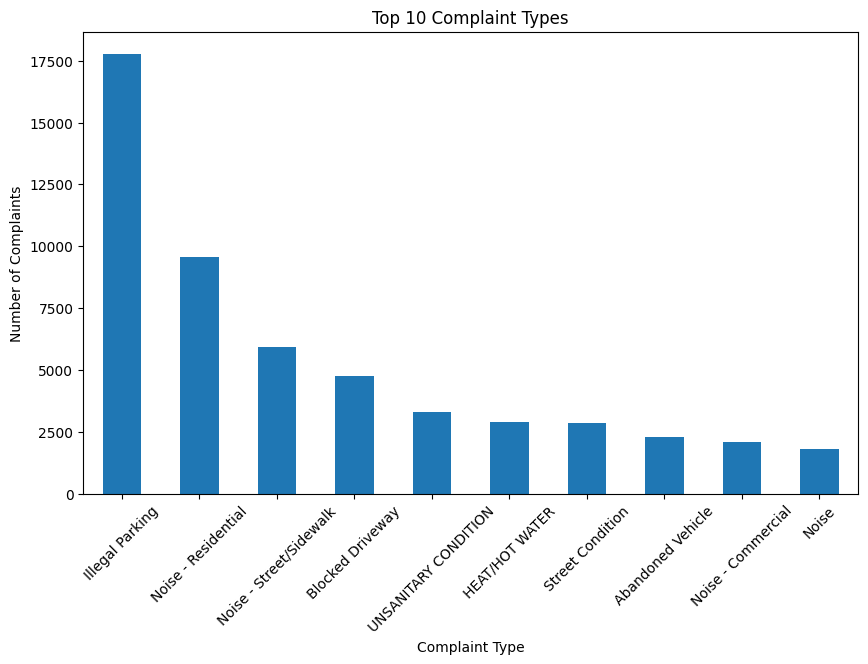

In [ ]:
# Display the most common complaint types
complaint_counts = df['complaint_type'].value_counts()
print("Top 10 Complaint Types:")
print(complaint_counts.head(10))

# Plot the top 10 complaint types as a bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
complaint_counts.head(10).plot(kind='bar')
plt.title('Top 10 Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.show()


## Q2: Analyze the Locations for the Top Complaint Type
Now that we have identified "Illegal Parking" as the most common complaint type, we will investigate which boroughs, ZIP codes, and streets have the highest number of such complaints. This will help prioritize specific areas for improvement.


Complaints by Borough:
borough
BROOKLYN         7515
QUEENS           5308
BRONX            2414
MANHATTAN        2047
STATEN ISLAND     492
Unspecified         3
Name: count, dtype: int64

Top 10 ZIP codes with Illegal Parking Complaints:
incident_zip
11201.0    575
11101.0    487
11385.0    426
11222.0    426
11421.0    400
11215.0    380
11239.0    377
11205.0    353
11103.0    341
11214.0    327
Name: count, dtype: int64

Top 10 Streets with Illegal Parking Complaints:
street_name
MESEROLE AVENUE            287
50 AVENUE                  242
ASTORIA BOULEVARD SOUTH    230
CLASSON AVENUE             213
UNION STREET               185
BROADWAY                   113
79 STREET                  110
DEAN STREET                104
SCHROEDERS AVENUE          102
4 AVENUE                    87
Name: count, dtype: int64


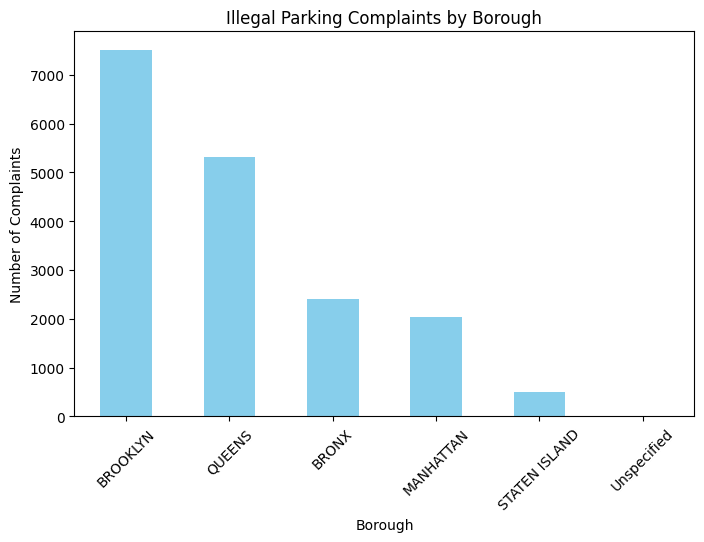

In [ ]:
# Filter data to only include 'Illegal Parking' complaints
illegal_parking_data = df[df['complaint_type'] == 'Illegal Parking']

# Count complaints by borough
borough_counts = illegal_parking_data['borough'].value_counts()
print("Complaints by Borough:")
print(borough_counts)

# Count complaints by ZIP code
zip_counts = illegal_parking_data['incident_zip'].value_counts().head(10)
print("\nTop 10 ZIP codes with Illegal Parking Complaints:")
print(zip_counts)

# Count complaints by street name
street_counts = illegal_parking_data['street_name'].value_counts().head(10)
print("\nTop 10 Streets with Illegal Parking Complaints:")
print(street_counts)

# Plot borough counts
plt.figure(figsize=(8, 5))
borough_counts.plot(kind='bar', color='skyblue')
plt.title('Illegal Parking Complaints by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.show()


## Q3:  Analyze Relationship with Building Characteristics
In this step, we will explore if there is a relationship between "Illegal Parking" complaints and any building-related characteristics. However, the dataset we are working with does not contain explicit building information (such as Building ID or House Number). Therefore, we will acknowledge the data limitation in this analysis.


In [ ]:
# Display the available columns to check for building-related data
print("Columns in dataset:")
print(df.columns)

# Since we do not have building-related columns, we acknowledge this in the analysis


Columns in dataset:
Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'location_type', 'incident_zip',
       'incident_address', 'street_name', 'cross_street_1', 'cross_street_2',
       'intersection_street_1', 'intersection_street_2', 'address_type',
       'city', 'landmark', 'facility_type', 'status', 'due_date',
       'resolution_description', 'resolution_action_updated_date',
       'community_board', 'bbl', 'borough', 'x_coordinate_state_plane',
       'y_coordinate_state_plane', 'open_data_channel_type',
       'park_facility_name', 'park_borough', 'vehicle_type',
       'taxi_company_borough', 'taxi_pick_up_location', 'bridge_highway_name',
       'bridge_highway_direction', 'road_ramp', 'bridge_highway_segment',
       'latitude', 'longitude', 'location'],
      dtype='object')


We reviewed the available columns in the dataset and found that there are no explicit building-related fields (such as Building ID or House Number). Therefore, we conclude that there is no direct way to analyze the relationship between "Illegal Parking" complaints and building characteristics within the current dataset.


##  Q4: Build a Predictive Model
We will now build a simple classification model to predict the possibility of "Illegal Parking" complaints based on available features in the dataset. This will help us understand the predictive power of these features.


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Create a target column: 1 if 'Illegal Parking', 0 otherwise
df['is_illegal_parking'] = df['complaint_type'].apply(lambda x: 1 if x == 'Illegal Parking' else 0)

# Select features
features = ['borough', 'incident_zip']
X = df[features]
y = df['is_illegal_parking']

# Encode categorical variables (borough)
X = pd.get_dummies(X, columns=['borough'])

# Handle missing values
X.fillna(0, inplace=True)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions and evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.99      0.90     24618
           1       0.47      0.06      0.10      5382

    accuracy                           0.82     30000
   macro avg       0.65      0.52      0.50     30000
weighted avg       0.76      0.82      0.76     30000



### Question 4: Predictive Model Results
We built a Random Forest classification model to predict whether a complaint is of type "Illegal Parking". The overall accuracy of the model was 82%, but the recall for predicting "Illegal Parking" complaints was low (6%). This suggests that the dataset is imbalanced and the features currently used may not be sufficient for accurate predictions. Further work could involve handling class imbalance and incorporating more features to improve model performance.


## Q5 :Analyze Temporal Trends
In this step, we will explore the temporal patterns of "Illegal Parking" complaints to determine whether there are specific times of day, days of the week, or months when these complaints peak. This analysis can help with resource allocation and planning.


<ipython-input-7-07acd070a7de>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  illegal_parking_data['hour'] = illegal_parking_data['created_date'].dt.hour
<ipython-input-7-07acd070a7de>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  illegal_parking_data['weekday'] = illegal_parking_data['created_date'].dt.day_name()
<ipython-input-7-07acd070a7de>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

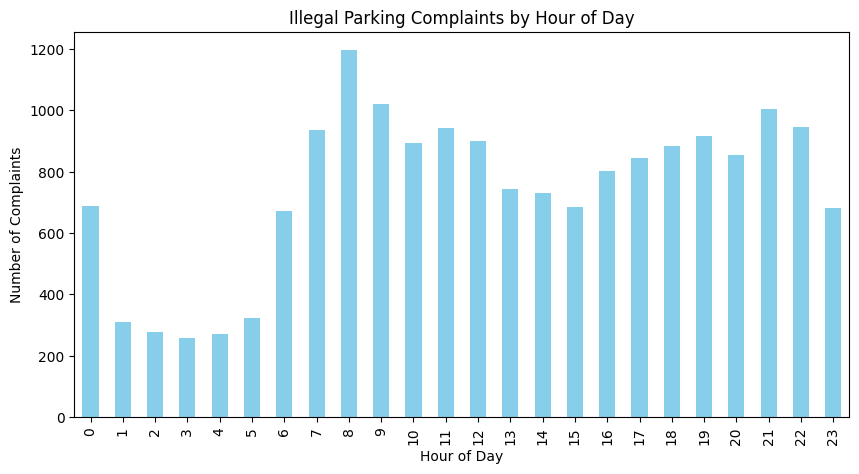

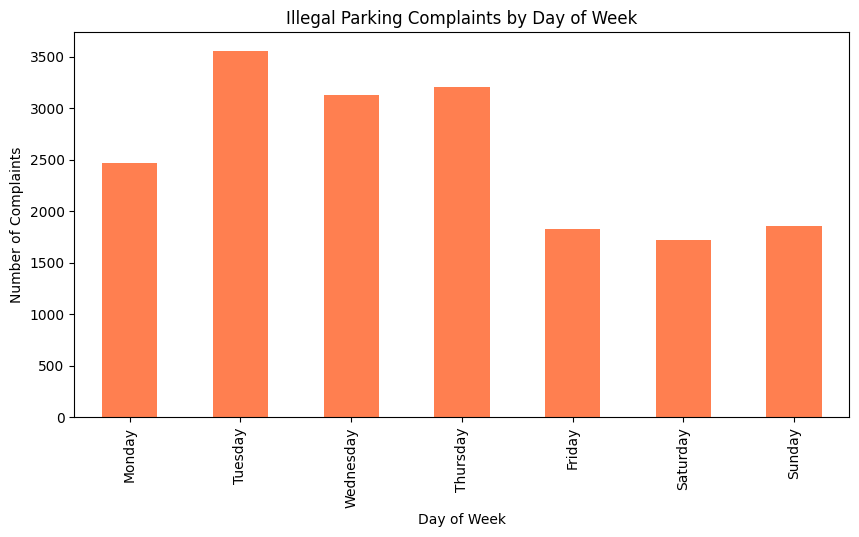

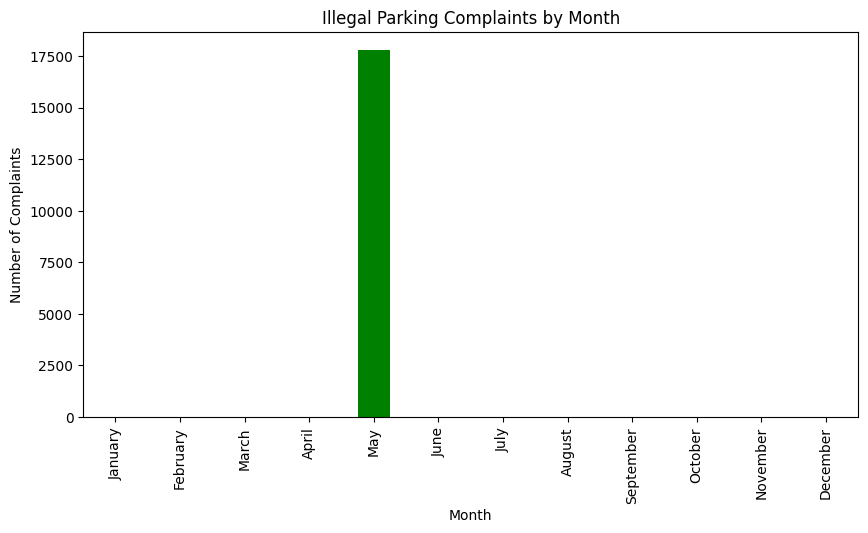

In [ ]:
# Convert 'created_date' to datetime
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

# Filter only 'Illegal Parking' complaints
illegal_parking_data = df[df['complaint_type'] == 'Illegal Parking']

# Extract hour, weekday, and month
illegal_parking_data['hour'] = illegal_parking_data['created_date'].dt.hour
illegal_parking_data['weekday'] = illegal_parking_data['created_date'].dt.day_name()
illegal_parking_data['month'] = illegal_parking_data['created_date'].dt.month_name()

# Plot hourly distribution
plt.figure(figsize=(10, 5))
illegal_parking_data['hour'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Illegal Parking Complaints by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Complaints')
plt.show()

# Plot weekday distribution
plt.figure(figsize=(10, 5))
illegal_parking_data['weekday'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar', color='coral')
plt.title('Illegal Parking Complaints by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Complaints')
plt.show()

# Plot monthly distribution
plt.figure(figsize=(10, 5))
illegal_parking_data['month'].value_counts().reindex(
    ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
).plot(kind='bar', color='green')
plt.title('Illegal Parking Complaints by Month')
plt.xlabel('Month')
plt.ylabel('Number of Complaints')
plt.show()_


## Question 5: Temporal Patterns for Illegal Parking Complaints
We analyzed the temporal patterns of "Illegal Parking" complaints using the available dataset. The findings are as follows:

- **Hour of Day:** Complaints tend to peak in the morning (around 7 to 11 AM) and in the evening (5 to 9 PM).
- **Day of Week:** The highest number of complaints occurs on Tuesdays and Wednesdays, while the lowest occurs on Fridays and weekends.
- **Month:** The highest number of complaints was observed in May. Other months did not show a clear pattern, likely due to the limited sample size used in this analysis.

Understanding these patterns can help the Department of Housing Preservation and Development allocate resources more effectively during peak hours and days.
